In [1]:
from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd
import torch

DATA_DIR = Path("../data")   # adapte si besoin

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print("Device :", device)

Device : cpu


In [2]:
# Arborescence (dossiers + nb de fichiers par extension)
print("=== Arborescence de data/ ===")
for p in sorted(DATA_DIR.rglob("*")):
    if p.is_dir():
        exts = Counter(f.suffix.lower() for f in p.iterdir() if f.is_file())
        rel = p.relative_to(DATA_DIR)
        print(f"{rel}/  ->  {dict(exts)}")

# Fichiers de labels / métadonnées éventuels (csv, txt, json)
print("\n=== Fichiers tabulaires / métadonnées ===")
for p in DATA_DIR.rglob("*"):
    if p.suffix.lower() in {".csv", ".txt", ".json", ".xlsx"}:
        print(p.relative_to(DATA_DIR))

# Aperçu d'une image
imgs = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
print(f"\nTotal images trouvées : {len(imgs)}")
if imgs:
    im = Image.open(imgs[0])
    print("Exemple :", imgs[0].name, "| taille :", im.size, "| mode :", im.mode)

=== Arborescence de data/ ===
avec_labels/  ->  {}
avec_labels\cancer/  ->  {'.jpg': 50}
avec_labels\normal/  ->  {'.jpg': 50}
sans_label/  ->  {'.jpg': 1406}

=== Fichiers tabulaires / métadonnées ===

Total images trouvées : 1506
Exemple : 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg | taille : (512, 512) | mode : RGB


In [3]:
import numpy as np

DATA_DIR = Path("../data")
OUT_DIR = Path("../outputs"); OUT_DIR.mkdir(exist_ok=True)

rows = []
for p in DATA_DIR.rglob("*.jpg"):
    parts = p.relative_to(DATA_DIR).parts
    if parts[0] == "avec_labels":
        rows.append({"path": str(p), "split": "labeled", "label": parts[1]})
    elif parts[0] == "sans_label":
        rows.append({"path": str(p), "split": "unlabeled", "label": None})

df = pd.DataFrame(rows).sort_values("path").reset_index(drop=True)
df.to_csv(OUT_DIR / "inventory.csv", index=False)

print(df.groupby(["split", "label"], dropna=False).size())
print("\nTotal :", len(df))

split      label 
labeled    cancer      50
           normal      50
unlabeled  NaN       1406
dtype: int64

Total : 1506


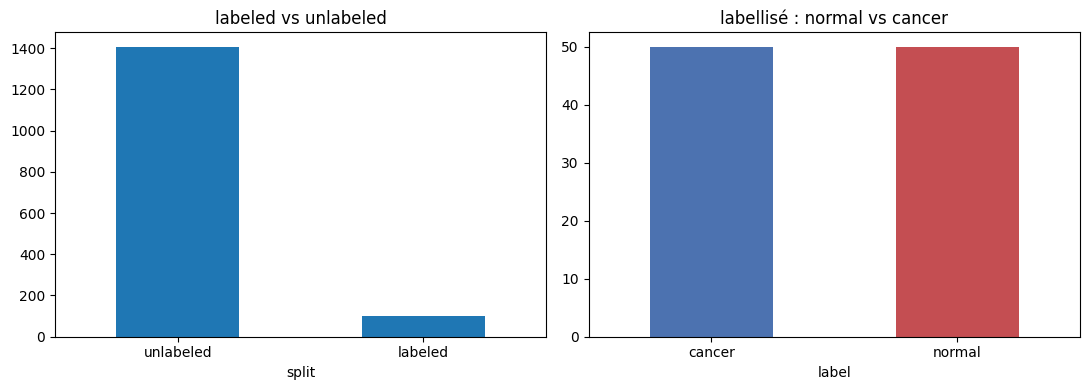

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["split"].value_counts().plot.bar(ax=axes[0], title="labeled vs unlabeled", rot=0)
df[df.split=="labeled"]["label"].value_counts().plot.bar(
    ax=axes[1], title="labellisé : normal vs cancer", rot=0, color=["#4c72b0", "#c44e52"])
plt.tight_layout(); plt.show()

In [5]:
from collections import Counter

sizes, modes = Counter(), Counter()
for p in df["path"]:
    with Image.open(p) as im:
        sizes[im.size] += 1
        modes[im.mode] += 1
print("Tailles :", dict(sizes))
print("Modes   :", dict(modes))

def is_grayscale(path):
    arr = np.asarray(Image.open(path))
    if arr.ndim == 2:
        return True
    return np.allclose(arr[..., 0], arr[..., 1]) and np.allclose(arr[..., 1], arr[..., 2])

sample = df.sample(30, random_state=0)["path"]
print("\nÉchantillon (30 imgs) : niveaux de gris dupliqué (R=G=B) ?",
      all(is_grayscale(p) for p in sample))

Tailles : {(512, 512): 1506}
Modes   : {'RGB': 1506}

Échantillon (30 imgs) : niveaux de gris dupliqué (R=G=B) ? True


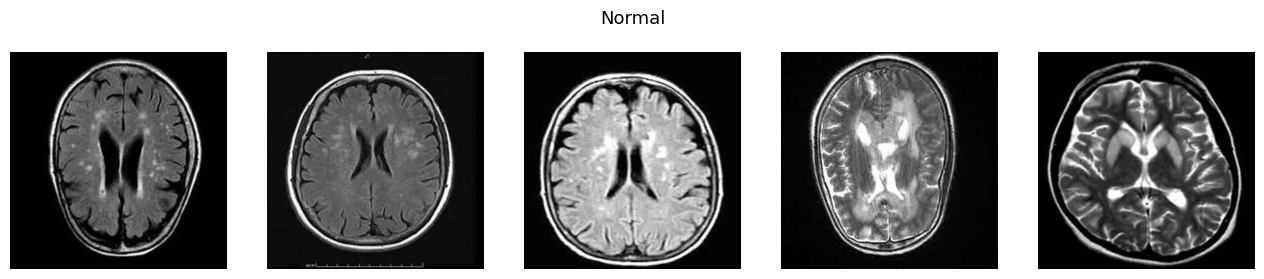

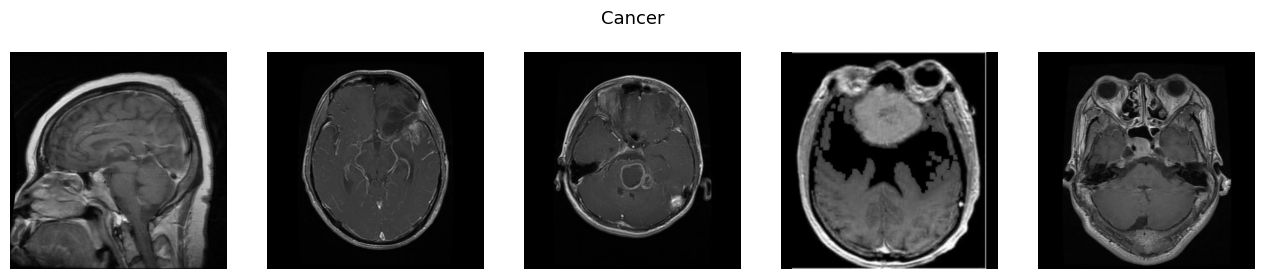

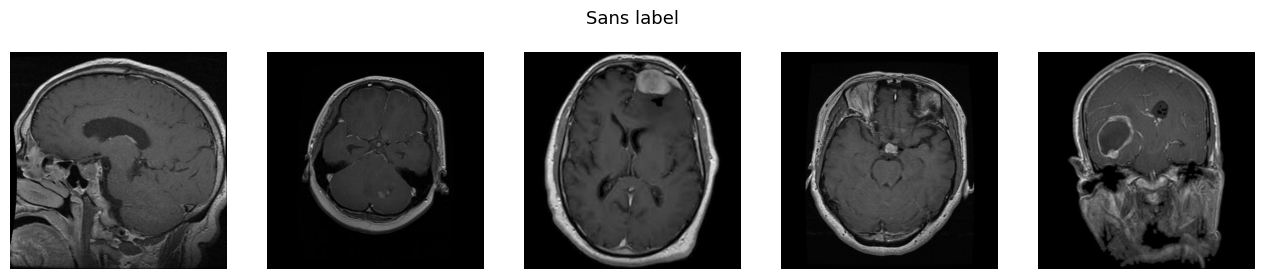

In [6]:
def show_samples(paths, title, n=5):
    paths = list(paths)[:n]
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.8))
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p))
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

show_samples(df[df.label == "normal"]["path"], "Normal")
show_samples(df[df.label == "cancer"]["path"], "Cancer")
show_samples(df[df.split == "unlabeled"]["path"], "Sans label")

# --- 02_feature_extraction.ipynb ---

# Feature Extraction

In [7]:
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from tqdm import tqdm

OUT_DIR = Path("../outputs")
df = pd.read_csv(OUT_DIR / "inventory.csv")
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device :", device, "| images :", len(df))

Device : cpu | images : 1506


In [8]:
weights = ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()   # resize + center crop 224 + normalisation ImageNet
print(preprocess)

model = models.resnet50(weights=weights)
model.fc = nn.Identity()            # on retire la tête de classification -> sortie 2048-d
model.eval().to(device)
for p in model.parameters():        # on gèle tout
    p.requires_grad = False

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Paramètres entraînables :", n_trainable, "(doit être 0)")

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
Paramètres entraînables : 0 (doit être 0)


Choix de la couche d'extraction. Nous extrayons les features à la sortie de la dernière couche convolutionnelle de ResNet50, juste avant la couche fully-connected de classification (remplacée par nn.Identity()), soit un vecteur de 2048 dimensions après global average pooling. Cette couche fournit une représentation visuelle générique et de haut niveau (formes, textures), adaptée au transfert vers un domaine différent d'ImageNet. Les couches plus profondes (la tête FC) sont spécialisées sur les 1000 classes d'ImageNet et donc peu pertinentes pour des IRM ; les couches plus précoces ne capturent que des motifs bas niveau (contours). Le réseau est entièrement gelé : il sert uniquement d'extracteur de features.

In [9]:
class ImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths); self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img)

ds = ImageDataset(df["path"].tolist(), preprocess)
# shuffle=False -> l'ordre des features correspondra exactement aux lignes de df
dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

In [10]:
feats = []
with torch.no_grad():
    for batch in tqdm(dl, desc="Extraction"):
        out = model(batch.to(device))     # (B, 2048)
        feats.append(out.cpu().numpy())

features = np.concatenate(feats, axis=0)
np.save(OUT_DIR / "features.npy", features)

print("Shape features :", features.shape)         # attendu (1506, 2048)
print("Alignées avec df :", features.shape[0] == len(df))
print("NaN ?", np.isnan(features).any(), "| moyenne :", features.mean().round(3),
      "| écart-type :", features.std().round(3))

Extraction: 100%|██████████| 48/48 [00:43<00:00,  1.11it/s]

Shape features : (1506, 2048)
Alignées avec df : True
NaN ? False | moyenne : 0.101 | écart-type : 0.304


Images atypiques : 31 / 1506
split
unlabeled    31
dtype: int64


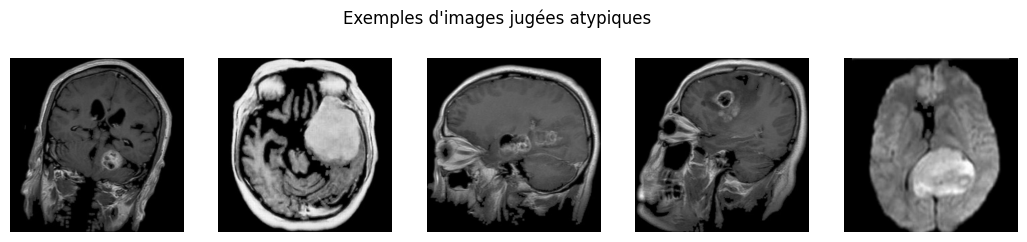

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd

OUT_DIR = Path("../outputs")
X = np.load(OUT_DIR / "features.npy")
inv = pd.read_csv(OUT_DIR / "inventory.csv")
Xs = StandardScaler().fit_transform(X)

iso = IsolationForest(contamination=0.02, random_state=0)
inv["outlier"] = (iso.fit_predict(Xs) == -1)
print("Images atypiques :", int(inv["outlier"].sum()), "/", len(inv))
print(inv[inv["outlier"]].groupby("split").size())

flagged = inv[inv["outlier"]]["path"].tolist()[:5]
fig, ax = plt.subplots(1, len(flagged), figsize=(2.6*len(flagged), 2.8))
for a, p in zip(ax, flagged):
    a.imshow(Image.open(p)); a.axis("off")
fig.suptitle("Exemples d'images jugées atypiques"); plt.show()

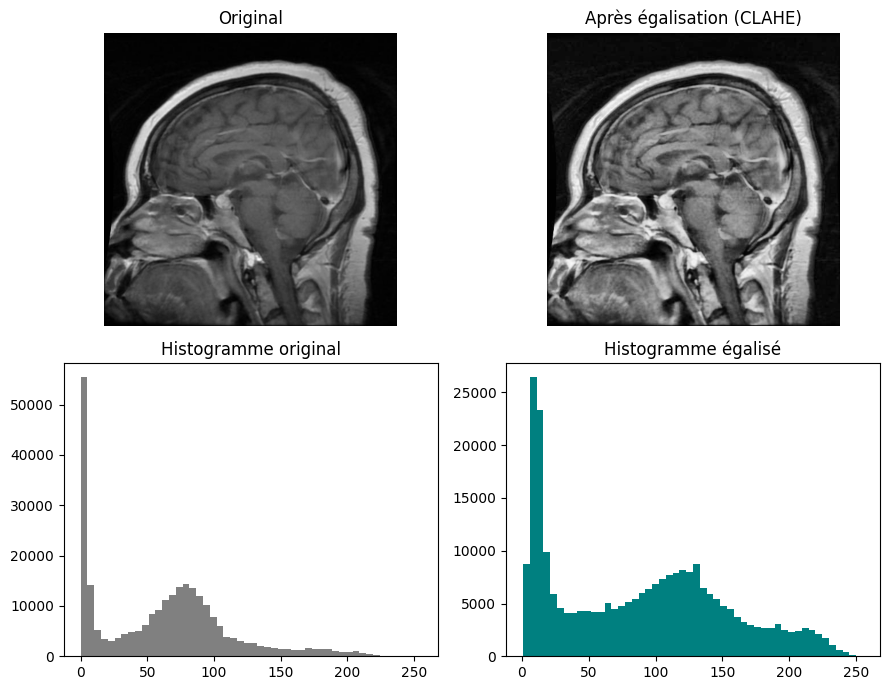

In [12]:
import cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

OUT_DIR = Path("../outputs")
inv = pd.read_csv(OUT_DIR / "inventory.csv")

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
p = inv["path"].iloc[0]
orig = np.array(Image.open(p).convert("L"))
eq = clahe.apply(orig)

fig, ax = plt.subplots(2, 2, figsize=(9, 7))
ax[0,0].imshow(orig, cmap="gray"); ax[0,0].set_title("Original"); ax[0,0].axis("off")
ax[0,1].imshow(eq, cmap="gray"); ax[0,1].set_title("Après égalisation (CLAHE)"); ax[0,1].axis("off")
ax[1,0].hist(orig.ravel(), bins=50, color="gray");  ax[1,0].set_title("Histogramme original")
ax[1,1].hist(eq.ravel(), bins=50, color="teal");    ax[1,1].set_title("Histogramme égalisé")
plt.tight_layout(); plt.show()

In [13]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
weights = ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()
model = models.resnet50(weights=weights); model.fc = nn.Identity(); model.eval().to(device)
for prm in model.parameters(): prm.requires_grad = False

class CLAHEDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths); self.transform = transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        g = self.clahe.apply(np.array(Image.open(self.paths[i]).convert("L")))
        return self.transform(Image.fromarray(g).convert("RGB"))

dl = DataLoader(CLAHEDataset(inv["path"].tolist(), preprocess), batch_size=32, shuffle=False)
feats = []
with torch.no_grad():
    for b in tqdm(dl, desc="Extraction CLAHE"):
        feats.append(model(b.to(device)).cpu().numpy())
features_eq = np.concatenate(feats)
np.save(OUT_DIR / "features_eq.npy", features_eq)
print("features_eq :", features_eq.shape)

Extraction CLAHE: 100%|██████████| 48/48 [00:44<00:00,  1.09it/s]

features_eq : (1506, 2048)


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, roc_auc_score
from sklearn.semi_supervised import LabelSpreading
from sklearn.model_selection import StratifiedShuffleSplit

path2idx = {p: i for i, p in enumerate(inv["path"])}
mask = (inv["split"] == "labeled").to_numpy()
sl = inv[inv["split"] == "labeled"].copy()
sl["y"] = sl["label"].map({"normal": 0, "cancer": 1})
idx_all = np.array([path2idx[p] for p in sl["path"]]); true_all = sl["y"].to_numpy()

def evaluate_features(X, name):
    Xp = PCA(50, random_state=0).fit_transform(StandardScaler().fit_transform(X))
    cl = KMeans(2, n_init=10, random_state=0).fit_predict(Xp)
    ari = adjusted_rand_score(true_all, cl[idx_all])
    aucs = []
    for seed in range(5):
        tr, te = next(StratifiedShuffleSplit(1, test_size=0.3, random_state=seed).split(idx_all, true_all))
        y = np.full(len(inv), -1); y[idx_all[tr]] = true_all[tr]
        m = LabelSpreading(kernel="knn", n_neighbors=12, alpha=0.2, max_iter=60).fit(Xp, y)
        aucs.append(roc_auc_score(true_all[te], m.predict_proba(Xp[idx_all[te]])[:, 1]))
    print(f"{name:18s} | ARI={ari:.3f} | AUC={np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

evaluate_features(np.load(OUT_DIR / "features.npy"),    "Sans égalisation")
evaluate_features(np.load(OUT_DIR / "features_eq.npy"), "Avec égalisation")

Sans égalisation   | ARI=0.124 | AUC=0.947 ± 0.022
Avec égalisation   | ARI=0.224 | AUC=0.975 ± 0.009


Efficacité du processus. L'extraction des 1 506 embeddings prend ~46 s sur CPU (batchs de 32). La matrice de features finale est de taille 1506 × 2048 en float32, soit ≈ 12 Mo en mémoire (1506 × 2048 × 4 octets) — négligeable. Les features sont calculées une seule fois puis sauvegardées (features.npy / features_eq.npy) et rechargées dans les notebooks suivants, ce qui évite tout recalcul coûteux. L'approche reste donc viable même sans GPU.



# --- 03_clustering.ipynb ---

# Clustering

Justification des choix de modèles. ResNet50 (He et al., 2016) est un standard du transfer learning : ses connexions résiduelles permettent un entraînement profond stable, et ses features pré-entraînées sur ImageNet transfèrent bien vers l'imagerie médicale. K-Means est choisi pour le clustering car nous connaissons le nombre de groupes attendu (k=2), et DBSCAN est testé en complément pour sa capacité à détecter des formes non sphériques et du bruit. Pour le semi-supervisé, Label Spreading (Zhou et al., 2004) propage les labels via un graphe de similarité ; il est particulièrement adapté quand peu de données sont étiquetées mais que la structure des features est informative — ce qui est exactement notre cas, et ce que confirment nos résultats.



In [15]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, accuracy_score

OUT_DIR = Path("../outputs")
df = pd.read_csv(OUT_DIR / "inventory.csv")
X = np.load(OUT_DIR / "features_eq.npy")
mask = df["split"] == "labeled"                 # les 100 fortement labellisées
print(X.shape, "| labellisées :", mask.sum())

(1506, 2048) | labellisées : 100


In [16]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X_scaled)
print("Variance expliquée par 50 composantes :", pca.explained_variance_ratio_.sum().round(3))

Variance expliquée par 50 composantes : 0.452


In [17]:
km = KMeans(n_clusters=2, n_init=10, random_state=0)
df["cluster"] = km.fit_predict(X_pca)

y_true = df.loc[mask, "label"].values
c_lab  = df.loc[mask, "cluster"].values

print("ARI (K-Means, sur les 100 labellisées) :", round(adjusted_rand_score(y_true, c_lab), 3))
print("\nCroisement cluster × vrai label :")
print(pd.crosstab(df.loc[mask, "label"], df.loc[mask, "cluster"]))

ARI (K-Means, sur les 100 labellisées) : 0.224

Croisement cluster × vrai label :
cluster   0   1
label          
cancer   26  24
normal    2  48


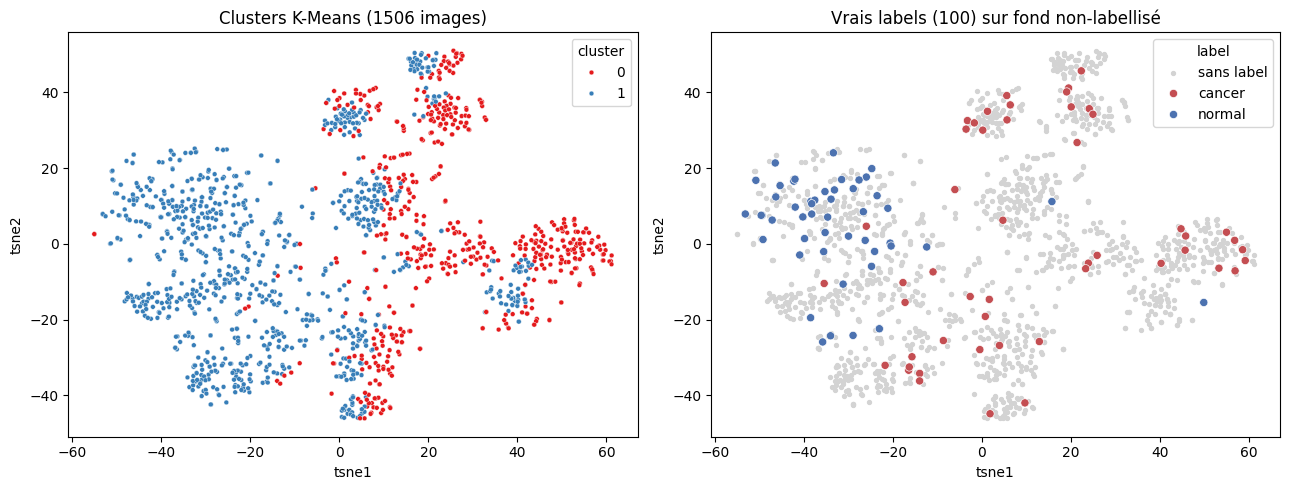

In [18]:
X_2d = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_pca)
df["tsne1"], df["tsne2"] = X_2d[:, 0], X_2d[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="tsne1", y="tsne2", hue="cluster", palette="Set1", s=12, ax=ax[0])
ax[0].set_title("Clusters K-Means (1506 images)")

ax[1].scatter(df[~mask]["tsne1"], df[~mask]["tsne2"], c="lightgray", s=8, label="sans label")
sns.scatterplot(data=df[mask], x="tsne1", y="tsne2", hue="label",
                palette={"normal": "#4c72b0", "cancer": "#c44e52"}, s=35, ax=ax[1])
ax[1].set_title("Vrais labels (100) sur fond non-labellisé")
plt.tight_layout(); plt.show()

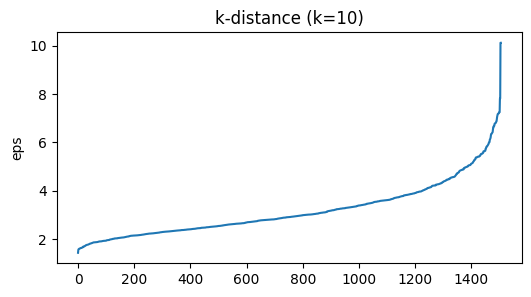

DBSCAN -> clusters : 22 | points 'bruit' : 302
ARI DBSCAN : 0.149


In [19]:
# courbe des k-distances pour repérer le "coude" -> eps
from sklearn.neighbors import NearestNeighbors
d = np.sort(NearestNeighbors(n_neighbors=10).fit(X_2d).kneighbors(X_2d)[0][:, -1])
plt.figure(figsize=(6, 3)); plt.plot(d); plt.title("k-distance (k=10)"); plt.ylabel("eps"); plt.show()

db = DBSCAN(eps=3.0, min_samples=10).fit(X_2d)   # ajuste eps selon le coude ci-dessus
df["dbscan"] = db.labels_
n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print("DBSCAN -> clusters :", n_cl, "| points 'bruit' :", int((db.labels_ == -1).sum()))
print("ARI DBSCAN :", round(adjusted_rand_score(y_true, df.loc[mask, "dbscan"].values), 3))

In [20]:
# numéro de cluster -> classe, via vote majoritaire sur les SEULES labellisées
mapping = df[mask].groupby("cluster")["label"].agg(lambda s: s.value_counts().idxmax())
print("Mapping cluster -> classe :", mapping.to_dict())

pred_lab = df.loc[mask, "cluster"].map(mapping)
print("Accuracy du clustering sur les 100 labellisées :",
      round(accuracy_score(df.loc[mask, "label"], pred_lab), 3))

df["weak_label"] = df["cluster"].map(mapping)

# >>> jeux STRICTEMENT séparés <
strong = df[mask][["path", "label"]].rename(columns={"label": "y"})
weak   = df[~mask][["path", "weak_label"]].rename(columns={"weak_label": "y"})
strong.to_csv(OUT_DIR / "strong_labeled.csv", index=False)
weak.to_csv(OUT_DIR / "weak_labeled.csv", index=False)

print("\nFortement labellisé :", len(strong), "| Faiblement labellisé :", len(weak))
print(weak["y"].value_counts())

Mapping cluster -> classe : {0: 'cancer', 1: 'normal'}
Accuracy du clustering sur les 100 labellisées : 0.74

Fortement labellisé : 100 | Faiblement labellisé : 1406
y
normal    901
cancer    505
Name: count, dtype: int64
